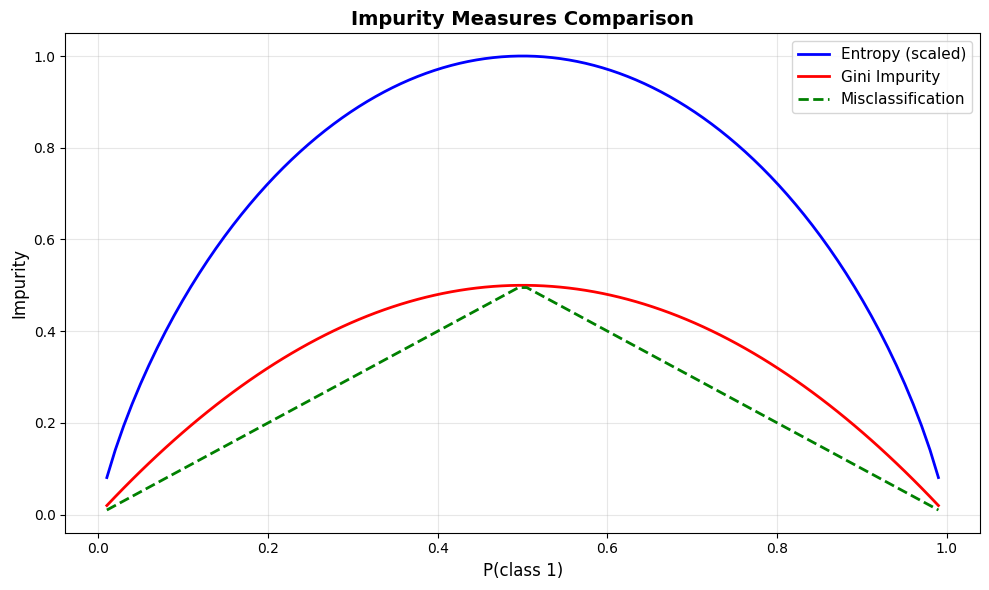

INFORMATION GAIN EXAMPLE
Parent entropy: H = 0.9403
After split: H = 0.6935
Information Gain = 0.2467


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def entropy(probs):
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def gini(probs):
    return 1 - np.sum(probs**2)

# Compare entropy and gini for binary classification
p = np.linspace(0.01, 0.99, 100)
entropy_vals = [entropy(np.array([pi, 1-pi])) for pi in p]
gini_vals = [gini(np.array([pi, 1-pi])) for pi in p]
misclass = [min(pi, 1-pi) for pi in p]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p, entropy_vals, 'b-', linewidth=2, label='Entropy (scaled)')
ax.plot(p, gini_vals, 'r-', linewidth=2, label='Gini Impurity')
ax.plot(p, misclass, 'g--', linewidth=2, label='Misclassification')
ax.set_xlabel('P(class 1)', fontsize=12)
ax.set_ylabel('Impurity', fontsize=12)
ax.set_title('Impurity Measures Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('impurity_measures.png', dpi=150)
plt.show()

# Information Gain Example
print("=" * 50)
print("INFORMATION GAIN EXAMPLE")
print("=" * 50)
# Dataset: 14 examples, 9 Yes, 5 No (play tennis?)
p_yes, p_no = 9/14, 5/14
H_parent = entropy(np.array([p_yes, p_no]))
print(f"Parent entropy: H = {H_parent:.4f}")

# Split on "Outlook" feature:
# Sunny: 2 Yes, 3 No → H = 0.971
# Overcast: 4 Yes, 0 No → H = 0.0
# Rainy: 3 Yes, 2 No → H = 0.971
H_sunny = entropy(np.array([2/5, 3/5]))
H_overcast = entropy(np.array([1.0]))  # Pure
H_rainy = entropy(np.array([3/5, 2/5]))

H_after = (5/14) * H_sunny + (4/14) * H_overcast + (5/14) * H_rainy
IG = H_parent - H_after
print(f"After split: H = {H_after:.4f}")
print(f"Information Gain = {IG:.4f}")

In [2]:
import numpy as np

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # Leaf value (class label)

class DecisionTreeFromScratch:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    
    def _gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    
    def _best_split(self, X, y):
        best_gain = -1
        best_feature, best_threshold = None, None
        parent_gini = self._gini(y)
        n = len(y)
        
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                left_gini = self._gini(y[left_mask])
                right_gini = self._gini(y[right_mask])
                
                weighted_gini = (np.sum(left_mask)/n * left_gini + 
                                np.sum(right_mask)/n * right_gini)
                gain = parent_gini - weighted_gini
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X, y, depth=0):
        n_classes = len(np.unique(y))
        
        # Stopping conditions
        if (depth >= self.max_depth or n_classes == 1 or 
            len(y) < self.min_samples_split):
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
        
        feature, threshold, gain = self._best_split(X, y)
        
        if gain <= 0:
            return Node(value=np.bincount(y).argmax())
        
        left_mask = X[:, feature] <= threshold
        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        
        return Node(feature=feature, threshold=threshold, left=left, right=right)
    
    def fit(self, X, y):
        self.root = self._build_tree(X, y)
        return self
    
    def _predict_single(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_single(x, node.left)
        return self._predict_single(x, node.right)
    
    def predict(self, X):
        return np.array([self._predict_single(x, self.root) for x in X])
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# Test
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

tree = DecisionTreeFromScratch(max_depth=5)
tree.fit(X_train, y_train)
print(f"From-scratch accuracy: {tree.score(X_test, y_test):.2%}")

From-scratch accuracy: 100.00%


Training accuracy: 0.9583
Test accuracy:     1.0000


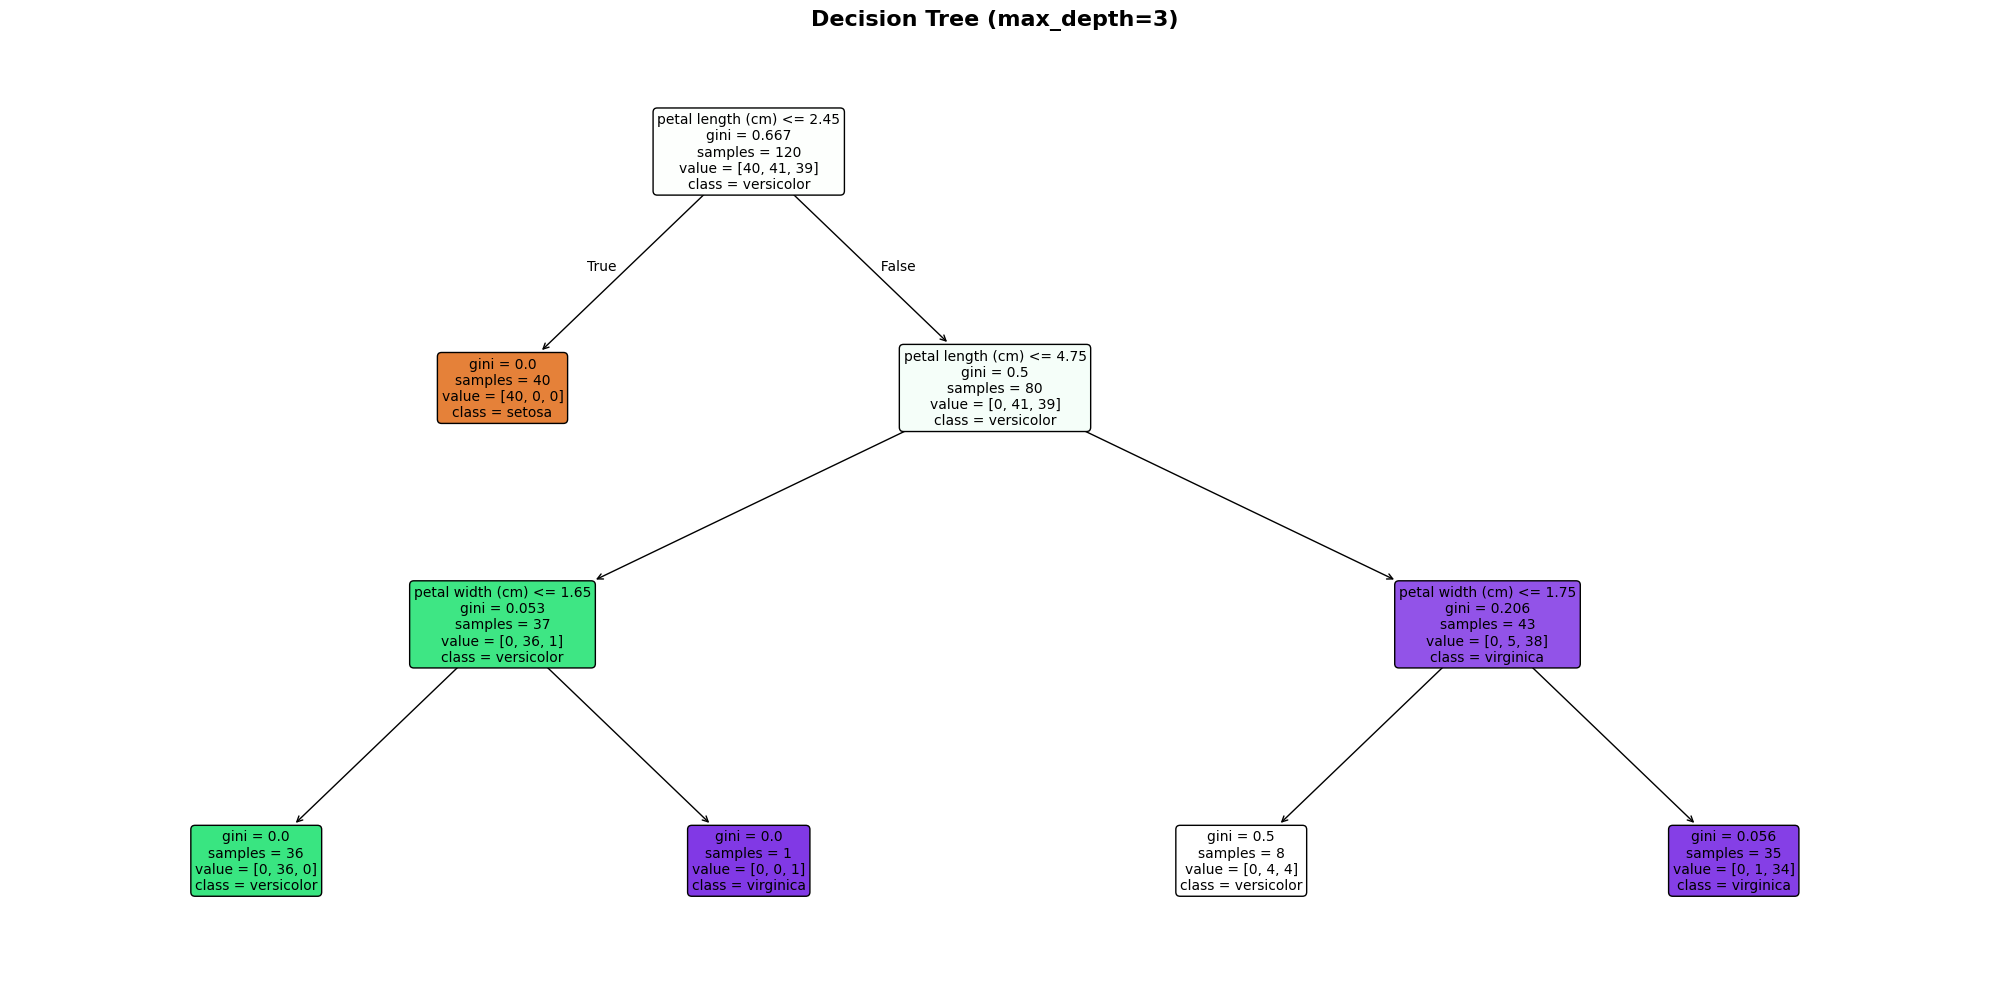

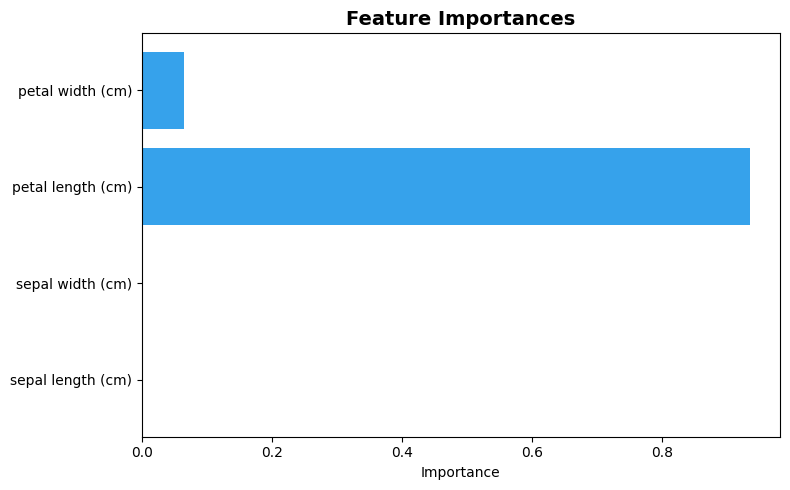

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

# Train
tree = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
tree.fit(X_train, y_train)

print(f"Training accuracy: {tree.score(X_train, y_train):.4f}")
print(f"Test accuracy:     {tree.score(X_test, y_test):.4f}")

# Visualize the tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names,filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title('Decision Tree (max_depth=3)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_visual.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
importances = tree.feature_importances_
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(iris.feature_names, importances, color='#36A2EB')
ax.set_title('Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('tree_importance.png', dpi=150)
plt.show()